In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta
import os

%matplotlib inline

In [9]:
old_files = ['CDA_inmet.dat', 'FDS_inmet.dat', 'MTR_SSA.dat', 'SSA_inmet.dat']

path = 'dados-brutos/'
new_files = [f for f in os.listdir(path) if f.endswith('.CSV') and 'RADIO' in f]

path = 'old-databases/'
old_df = pd.read_csv(path + old_files[3], sep=',')
old_df.index = pd.to_datetime(old_df['year month day hour'.split()])

In [10]:
new_files

['INMET_NE_BA_A456_SALVADOR (RADIO FAROL)_01-01-2019_A_31-12-2019.CSV',
 'INMET_NE_BA_A456_SALVADOR (RADIO FAROL)_01-01-2020_A_31-12-2020.CSV',
 'INMET_NE_BA_A456_SALVADOR (RADIO FAROL)_01-01-2021_A_31-10-2021.CSV',
 'INMET_NE_BA_A456_SALVADOR (RADIO FAROL)_10-03-2018_A_31-12-2018.CSV']

In [11]:
path = 'dados-brutos/'
df = pd.read_csv(path + new_files[3], sep=';', skiprows=list(range(8)))

df2 = pd.read_csv(path + new_files[0], sep=';', skiprows=list(range(8)))

df3 = pd.read_csv(path + new_files[1], sep=';', skiprows=list(range(8)))

df4 = pd.read_csv(path + new_files[2], sep=';', skiprows=list(range(8)))

In [12]:
colunas = list(enumerate(df.columns))
colunas

[(0, 'data'),
 (1, 'horautc'),
 (2, 'precip'),
 (3, 'pressao'),
 (4, 'pressao_max'),
 (5, 'pressao_min'),
 (6, 'radiacao_kjmin'),
 (7, 'temperatura_bulbo_seco'),
 (8, 'temperatura_orvalho'),
 (9, 'temperatura_mx'),
 (10, 'temperatura_mn'),
 (11, 'temperatura_orvalho_max'),
 (12, 'temperatura_orvalho_min'),
 (13, 'umidade_max'),
 (14, 'umidade_min'),
 (15, 'umidade'),
 (16, 'vento_dir'),
 (17, 'vento_rajada'),
 (18, 'vento_vel'),
 (19, 'Unnamed: 19')]

In [13]:
old_df.columns

Index(['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS',
       'u', 'v', 'precip', 'e', 'q', 'theta', 'Sw_dw'],
      dtype='object')

In [14]:
df['date'] = [datetime.strptime(x+y[:2], '%Y-%m-%d%H').replace(tzinfo=timezone.utc).astimezone(tz=None) for x,y in zip(df['data'], df['horautc'])]
df2['date'] = [datetime.strptime(x+y[:2], '%Y/%m/%d%H').replace(tzinfo=timezone.utc).astimezone(tz=None) for x,y in zip(df2['data'], df2['horautc'])]
df3['date'] = [datetime.strptime(x+y[:2], '%Y/%m/%d%H').replace(tzinfo=timezone.utc).astimezone(tz=None) for x,y in zip(df3['data'], df3['horautc'])]
df4['date'] = [datetime.strptime(x+y[:2], '%Y/%m/%d%H').replace(tzinfo=timezone.utc).astimezone(tz=None) for x,y in zip(df4['data'], df4['horautc'])]

In [17]:
df.index = df['date']
df2.index = df2['date']
df3.index = df3['date']
df4.index = df4['date']

df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['hour'] = df.index.hour

df2['year'] = df2.index.year
df2['month'] = df2.index.month
df2['day'] = df2.index.day
df2['hour'] = df2.index.hour

df3['year'] = df3.index.year
df3['month'] = df3.index.month
df3['day'] = df3.index.day
df3['hour'] = df3.index.hour

df4['year'] = df4.index.year
df4['month'] = df4.index.month
df4['day'] = df4.index.day
df4['hour'] = df4.index.hour

In [18]:
df['T'] = (df['temperatura_mx'] + df['temperatura_mn'])/2
df['Td'] = (df['temperatura_orvalho_max'] + df['temperatura_orvalho_min'])/2
df['ur'] = (df['umidade_max'] + df['umidade_min'])/2
df['pressure'] = (df['pressao_max'] + df['pressao_min'])/2
df['WD'] = df['vento_dir']
df['WS'] = df['vento_vel']
df['u'] = -df['WS']*np.sin(df['WD'])
df['v'] = -df['WS']*np.cos(df['WD'])
df['Sw_dw'] = df['radiacao_kjmin'] * (16.6667/60)

df2['T'] = (df2['temperatura_mx'] + df2['temperatura_mn'])/2
df2['Td'] = (df2['temperatura_orvalho_max'] + df2['temperatura_orvalho_min'])/2
df2['ur'] = (df2['umidade_max'] + df2['umidade_min'])/2
df2['pressure'] = (df2['pressao_max'] + df2['pressao_min'])/2
df2['WD'] = df2['vento_dir']
df2['WS'] = df2['vento_vel']
df2['u'] = -df2['WS']*np.sin(df2['WD'])
df2['v'] = -df2['WS']*np.cos(df2['WD'])
df2['Sw_dw'] = df2['radiacao_kjmin'] * (16.6667/60)

df3['T'] = (df3['temperatura_mx'] + df3['temperatura_mn'])/2
df3['Td'] = (df3['temperatura_orvalho_max'] + df3['temperatura_orvalho_min'])/2
df3['ur'] = (df3['umidade_max'] + df3['umidade_min'])/2
df3['pressure'] = (df3['pressao_max'] + df3['pressao_min'])/2
df3['WD'] = df3['vento_dir']
df3['WS'] = df3['vento_vel']
df3['u'] = -df3['WS']*np.sin(df3['WD'])
df3['v'] = -df3['WS']*np.cos(df3['WD'])
df3['Sw_dw'] = df3['radiacao_kjmin'] * (16.6667/60)

df4['T'] = (df4['temperatura_mx'] + df4['temperatura_mn'])/2
df4['Td'] = (df4['temperatura_orvalho_max'] + df4['temperatura_orvalho_min'])/2
df4['ur'] = (df4['umidade_max'] + df4['umidade_min'])/2
df4['pressure'] = (df4['pressao_max'] + df4['pressao_min'])/2
df4['WD'] = df4['vento_dir']
df4['WS'] = df4['vento_vel']
df4['u'] = -df4['WS']*np.sin(df4['WD'])
df4['v'] = -df4['WS']*np.cos(df4['WD'])
df4['Sw_dw'] = df4['radiacao_kjmin'] * (16.6667/60)

In [19]:
df = df[['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS','u', 'v', 'precip', 'Sw_dw']]
df2 = df2[['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS','u', 'v', 'precip', 'Sw_dw']]
df3 = df3[['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS','u', 'v', 'precip', 'Sw_dw']]
df4 = df4[['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS','u', 'v', 'precip', 'Sw_dw']]

In [22]:
dft1 = pd.merge_ordered(df, df2)
dft1.index = pd.to_datetime(dft1['year month day hour'.split()])

dft2 = pd.merge_ordered(dft1, df3)
dft2.index = pd.to_datetime(dft2['year month day hour'.split()])

df_final = pd.merge_ordered(dft2, df4)
df_final.index = pd.to_datetime(df_final['year month day hour'.split()])

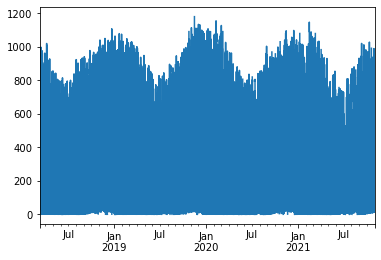

In [23]:
df_final['Sw_dw'].plot()

In [24]:
df_final.columns

Index(['year', 'month', 'day', 'hour', 'T', 'Td', 'ur', 'pressure', 'WD', 'WS',
       'u', 'v', 'precip', 'Sw_dw'],
      dtype='object')

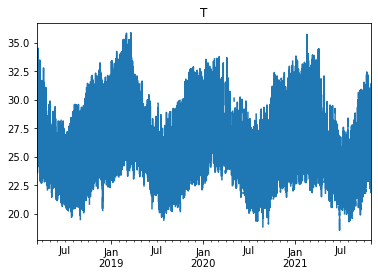

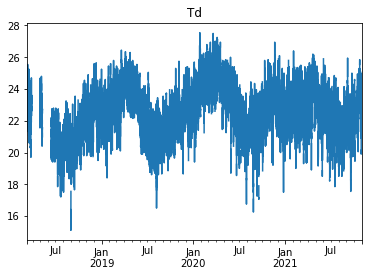

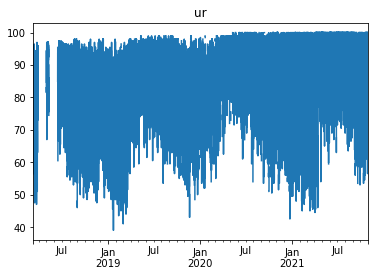

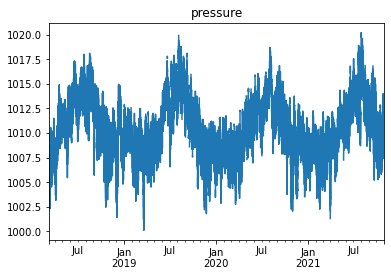

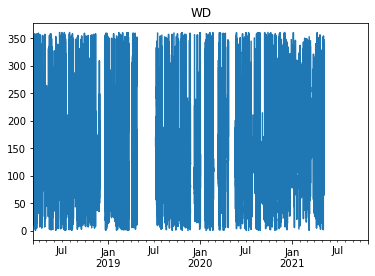

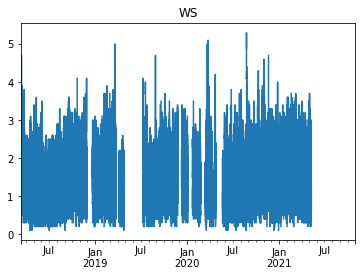

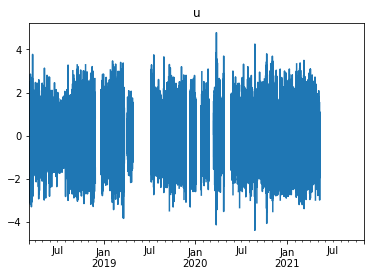

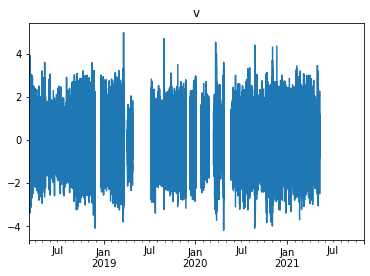

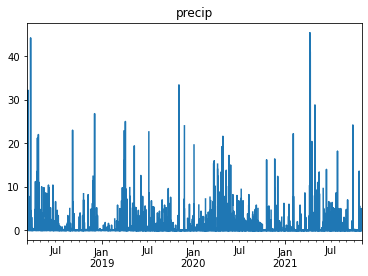

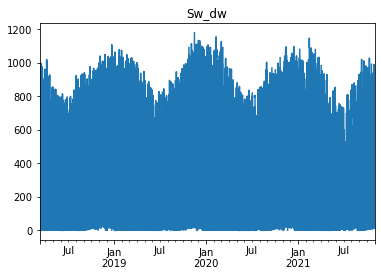

In [25]:
for col in df_final.columns:
    if col not in ['year', 'month', 'day', 'hour']:
        df_final[col] = df_final[col].astype(float)
        #check if there is values less than -500
        #df_final[col][df_final[col] < -500] = np.nan
        df_final[col].plot()
        plt.title(col)
        plt.show()
        plt.close()

In [26]:
df_final.to_csv('new-databases/SSA_farol_inmet_completo.dat', sep=';', index=False, na_rep='NaN')